# Statistical Analysis
Source file: Data/comparisons/comparison_summary.csv

Compares the different heuristic combinations using:
1. Mean, standard deviation
2. 95% confidence interval
3. Paired t-tests
4. Throughput rate (# of items/time unit)

Metrics analysed: `total_time` (makespan), `avg_order_time`

In [35]:
import pandas as pd

In [36]:
df_raw = pd.read_csv('Data/comparison/comparison_summary.csv')
df_raw.head(5)
print(f'Loaded {len(df_raw)} rows, {df_raw.shape[1]} columns')

rep_min = df_raw['replication'].min()
rep_max = df_raw['replication'].max()
print(f"Replications: {rep_min}-{rep_max}")

Loaded 516 rows, 15 columns
Replications: 1-25


In [37]:
order_options = df_raw['order_sequencing'].unique()
tote_options = df_raw['tote_sequencing'].unique()
item_options = df_raw['item_sequencing'].unique()

print(f"Order Sequencing Heuristics:")
for option in order_options:
    print(f"- {option}")

print(f"\nTote Sequencing Heuristics:")
for option in tote_options:
    print(f"- {option}")

print(f"\nItem Sequencing Heuristics:")
for option in item_options:
    print(f"- {option}")

Order Sequencing Heuristics:
- algorithm1_load_balance
- algorithm1b_stratified_balance
- algorithm2_tote_overlap
- algorithm3_itemtype_overlap
- algorithm4_combined_overlap
- fifo_all

Tote Sequencing Heuristics:
- smart_active_need
- smart_active_need_weighted
- fifo

Item Sequencing Heuristics:
- fixed
- critical_first


## 1. Descriptive Statistics — Mean, Std Dev, 95% CI


In [38]:
ALPHA = 0.05 # significance level


# Remove flawed / incomplete runs
df = df_raw[
    (df_raw['flawed_run'] == False) &
    (df_raw['all_orders_completed'] == True)
].copy()

# Build combo label
df['combo'] = (
    df['order_sequencing'] + ' | ' +
    df['tote_sequencing']  + ' | ' +
    df['item_sequencing']
)

# Throughput rate proxy
df['throughput_rate'] = df['item_sequence_length'] / df['total_time']

# All combos sorted by mean makespan (best = lowest first)
all_combos = (
    df.groupby('combo')['total_time'].mean()
    .sort_values()
    .index.tolist()
)

n_combos         = len(all_combos)
n_pairs          = n_combos * (n_combos - 1) // 2

rep_counts = df.groupby('combo')['replication'].count().rename('n_reps')
print(f'Combos discovered   : {n_combos}')
print(f'Total pairs         : {n_pairs}')
print(f'Alpha    : ({ALPHA}')
print(f'\nReplications per combo (sorted by mean makespan):')
print(rep_counts.reindex(all_combos).to_string())

Combos discovered   : 21
Total pairs         : 210
Alpha    : (0.05

Replications per combo (sorted by mean makespan):
combo
algorithm2_tote_overlap | smart_active_need_weighted | critical_first           22
algorithm2_tote_overlap | smart_active_need_weighted | fixed                    22
algorithm2_tote_overlap | smart_active_need | critical_first                    24
algorithm4_combined_overlap | smart_active_need_weighted | fixed                21
algorithm2_tote_overlap | smart_active_need | fixed                             23
algorithm4_combined_overlap | smart_active_need_weighted | critical_first       22
algorithm4_combined_overlap | smart_active_need | critical_first                23
algorithm4_combined_overlap | smart_active_need | fixed                         22
algorithm1_load_balance | smart_active_need | fixed                             18
algorithm1_load_balance | smart_active_need | critical_first                    20
algorithm1_load_balance | smart_active_need_w

In [39]:
from scipy import stats

# Calculate confidence interval with a confidence of ALPHA
def ci95(x):
    n   = len(x)
    se  = stats.sem(x)
    t   = stats.t.ppf(1 - ALPHA/2, df=n-1)
    return se * t

desc_rows = []
for combo in all_combos:
    sub = df[df['combo'] == combo]
    for col, label in [
        ('total_time',     'Makespan'),
        ('avg_order_time', 'Avg Order Time'),
        ('throughput_rate',  'Throughput Rate'),
    ]:
        vals    = sub[col].dropna()
        mean    = vals.mean()
        half_ci = ci95(vals)
        desc_rows.append({
            'Combo'   : combo,
            'Metric'  : label,
            'n'       : len(vals),
            'Mean'    : round(mean, 4),
            'Std Dev' : round(vals.std(), 6),
            'CI95 LB' : round(mean - half_ci, 4),
            'CI95 UB' : round(mean + half_ci, 4),
            'Min'     : round(vals.min(), 4),
            'Max'     : round(vals.max(), 4),
        })

desc_df = pd.DataFrame(desc_rows)
display(desc_df)

,Combo,Metric,n,Mean,Std Dev,CI95 LB,CI95 UB,Min,Max
0,algorithm2_tote_overlap | smart_active_need_we...,Makespan,22,218.3523,49.111732,196.5774,240.1272,153.7500,337.5000
1,algorithm2_tote_overlap | smart_active_need_we...,Avg Order Time,22,138.2231,37.639017,121.5349,154.9113,93.4091,239.3182
2,algorithm2_tote_overlap | smart_active_need_we...,Throughput Rate,22,0.2047,0.029379,0.1917,0.2178,0.1452,0.2538
3,algorithm2_tote_overlap | smart_active_need_we...,Makespan,22,220.5682,59.850666,194.0319,247.1045,153.7500,442.5000
4,algorithm2_tote_overlap | smart_active_need_we...,Avg Order Time,22,140.7490,48.300855,119.3336,162.1644,88.2955,326.2500
...,...,...,...,...,...,...,...,...,...
58,algorithm1b_stratified_balance | smart_active_...,Avg Order Time,14,200.0893,77.563831,155.3053,244.8733,95.7955,342.2727
59,algorithm1b_stratified_balance | smart_active_...,Throughput Rate,14,0.1504,0.051894,0.1204,0.1803,0.0715,0.2311
60,algorithm1b_stratified_balance | smart_active_...,Makespan,14,355.1786,152.101352,267.3579,442.9993,168.7500,652.5000
61,algorithm1b_stratified_balance | smart_active_...,Avg Order Time,14,225.2192,91.591012,172.3361,278.1022,96.4773,397.8409


## 2. Paired t-Tests — All Pairwise Combinations

Pairs matched on `replication` ID.

`mean_diff = A − B` --> negative means A is faster/better

In [40]:
from itertools import combinations

In [41]:
def paired_ttest(df, combo_a, combo_b, metric):
    a = df[df['combo'] == combo_a][['replication', metric]].set_index('replication').sort_index()
    b = df[df['combo'] == combo_b][['replication', metric]].set_index('replication').sort_index()
    merged = a.join(b, lsuffix='_a', rsuffix='_b').dropna()
    if len(merged) < 2:
        return None
    t, p      = stats.ttest_rel(merged[f'{metric}_a'], merged[f'{metric}_b'])
    n         = len(merged)
    d         = merged[f'{metric}_a'] - merged[f'{metric}_b']
    diff_mean = d.mean()
    diff_ci   = ci95(d)
    sig       = p < ALPHA
    return dict(
        combo_A   = combo_a,
        combo_B   = combo_b,
        n         = n,
        mean_diff = round(diff_mean, 4),
        ci95_diff = f'[{diff_mean - diff_ci:.4f}, {diff_mean + diff_ci:.4f}]',
        t_stat    = round(t, 4),
        p_value   = round(p, 6),
        sig       = '✓' if sig else '✗',
        winner    = (
            'A' if (sig and diff_mean < 0)
            else 'B' if (sig and diff_mean > 0)
            else '—'
        )
    )

all_pairs = list(combinations(all_combos, 2))
short_labels = {c: f'C{i+1}' for i, c in enumerate(all_combos)}
label_legend = pd.DataFrame([{'Code': short_labels[c], 'Combo': c} for c in all_combos])

ttest_results = {}
for metric, label in [
    ('total_time',     'MAKESPAN'),
    ('avg_order_time', 'AVG ORDER TIME'),
    ('throughput_rate',  'THROUGHPUT RATE'),
]:
    rows = [paired_ttest(df, a, b, metric) for a, b in all_pairs]
    rows = [r for r in rows if r is not None]
    result_df = pd.DataFrame(rows)
    ttest_results[metric] = result_df
    sig_count = (result_df['sig'] == '✓').sum()
    print(f'\n═══ {label} — {len(result_df)} pairs, {sig_count} significant at α={ALPHA} ═══')
    display(result_df)


═══ MAKESPAN — 210 pairs, 64 significant at α=0.05 ═══


,combo_A,combo_B,n,mean_diff,ci95_diff,t_stat,p_value,sig,winner
0,algorithm2_tote_overlap | smart_active_need_we...,algorithm2_tote_overlap | smart_active_need_we...,21,-6.4286,"[-17.3738, 4.5167]",-1.2252,0.234745,✗,—
1,algorithm2_tote_overlap | smart_active_need_we...,algorithm2_tote_overlap | smart_active_need | ...,21,-2.6786,"[-11.6649, 6.3077]",-0.6218,0.541117,✗,—
2,algorithm2_tote_overlap | smart_active_need_we...,algorithm4_combined_overlap | smart_active_nee...,19,-18.9474,"[-34.8701, -3.0246]",-2.5000,0.022308,✓,A
3,algorithm2_tote_overlap | smart_active_need_we...,algorithm2_tote_overlap | smart_active_need | ...,20,-5.0625,"[-17.7219, 7.5969]",-0.8370,0.412996,✗,—
4,algorithm2_tote_overlap | smart_active_need_we...,algorithm4_combined_overlap | smart_active_nee...,20,-18.0000,"[-33.2748, -2.7252]",-2.4665,0.023330,✓,A
...,...,...,...,...,...,...,...,...,...
205,algorithm1b_stratified_balance | smart_active_...,algorithm1b_stratified_balance | smart_active_...,11,-21.4773,"[-109.1041, 66.1496]",-0.5461,0.596959,✗,—
206,algorithm1b_stratified_balance | smart_active_...,algorithm1b_stratified_balance | smart_active_...,11,-46.7045,"[-131.3567, 37.9476]",-1.2293,0.247094,✗,—
207,algorithm3_itemtype_overlap | smart_active_nee...,algorithm1b_stratified_balance | smart_active_...,11,-12.9545,"[-107.6834, 81.7743]",-0.3047,0.766837,✗,—
208,algorithm3_itemtype_overlap | smart_active_nee...,algorithm1b_stratified_balance | smart_active_...,11,-43.9773,"[-134.2794, 46.3249]",-1.0851,0.303340,✗,—



═══ AVG ORDER TIME — 210 pairs, 83 significant at α=0.05 ═══


,combo_A,combo_B,n,mean_diff,ci95_diff,t_stat,p_value,sig,winner
0,algorithm2_tote_overlap | smart_active_need_we...,algorithm2_tote_overlap | smart_active_need_we...,21,-5.4221,"[-14.3475, 3.5034]",-1.2672,0.219645,✗,—
1,algorithm2_tote_overlap | smart_active_need_we...,algorithm2_tote_overlap | smart_active_need | ...,21,-1.7695,"[-7.9103, 4.3713]",-0.6011,0.554544,✗,—
2,algorithm2_tote_overlap | smart_active_need_we...,algorithm4_combined_overlap | smart_active_nee...,19,-17.1352,"[-31.8325, -2.4379]",-2.4494,0.024774,✓,A
3,algorithm2_tote_overlap | smart_active_need_we...,algorithm2_tote_overlap | smart_active_need | ...,20,-4.9602,"[-14.8971, 4.9767]",-1.0448,0.309237,✗,—
4,algorithm2_tote_overlap | smart_active_need_we...,algorithm4_combined_overlap | smart_active_nee...,20,-14.8295,"[-28.1446, -1.5145]",-2.3311,0.030914,✓,A
...,...,...,...,...,...,...,...,...,...
205,algorithm1b_stratified_balance | smart_active_...,algorithm1b_stratified_balance | smart_active_...,11,12.2727,"[-52.0520, 76.5974]",0.4251,0.679756,✗,—
206,algorithm1b_stratified_balance | smart_active_...,algorithm1b_stratified_balance | smart_active_...,11,-10.5372,"[-72.3586, 51.2842]",-0.3798,0.712052,✗,—
207,algorithm3_itemtype_overlap | smart_active_nee...,algorithm1b_stratified_balance | smart_active_...,11,28.6983,"[-33.9110, 91.3077]",1.0213,0.331177,✗,—
208,algorithm3_itemtype_overlap | smart_active_nee...,algorithm1b_stratified_balance | smart_active_...,11,3.6260,"[-55.7279, 62.9800]",0.1361,0.894427,✗,—



═══ THROUGHPUT RATE — 210 pairs, 66 significant at α=0.05 ═══


,combo_A,combo_B,n,mean_diff,ci95_diff,t_stat,p_value,sig,winner
0,algorithm2_tote_overlap | smart_active_need_we...,algorithm2_tote_overlap | smart_active_need_we...,21,0.0027,"[-0.0023, 0.0076]",1.1244,0.274155,✗,—
1,algorithm2_tote_overlap | smart_active_need_we...,algorithm2_tote_overlap | smart_active_need | ...,21,0.0024,"[-0.0061, 0.0108]",0.5845,0.565390,✗,—
2,algorithm2_tote_overlap | smart_active_need_we...,algorithm4_combined_overlap | smart_active_nee...,19,0.0149,"[0.0017, 0.0282]",2.3730,0.028987,✓,B
3,algorithm2_tote_overlap | smart_active_need_we...,algorithm2_tote_overlap | smart_active_need | ...,20,0.0013,"[-0.0055, 0.0082]",0.4054,0.689742,✗,—
4,algorithm2_tote_overlap | smart_active_need_we...,algorithm4_combined_overlap | smart_active_nee...,20,0.0135,"[0.0015, 0.0256]",2.3514,0.029649,✓,B
...,...,...,...,...,...,...,...,...,...
205,algorithm1b_stratified_balance | smart_active_...,algorithm1b_stratified_balance | smart_active_...,11,0.0061,"[-0.0219, 0.0342]",0.4866,0.637039,✗,—
206,algorithm1b_stratified_balance | smart_active_...,algorithm1b_stratified_balance | smart_active_...,11,0.0142,"[-0.0092, 0.0376]",1.3525,0.205997,✗,—
207,algorithm3_itemtype_overlap | smart_active_nee...,algorithm1b_stratified_balance | smart_active_...,11,0.0080,"[-0.0382, 0.0542]",0.3857,0.707780,✗,—
208,algorithm3_itemtype_overlap | smart_active_nee...,algorithm1b_stratified_balance | smart_active_...,11,0.0181,"[-0.0259, 0.0622]",0.9175,0.380489,✗,—


## 3. P-value Heatmaps

Blue borders = significant after Bonferroni correction. Combos ordered best → worst makespan.

In [42]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

P-value matrices cached.


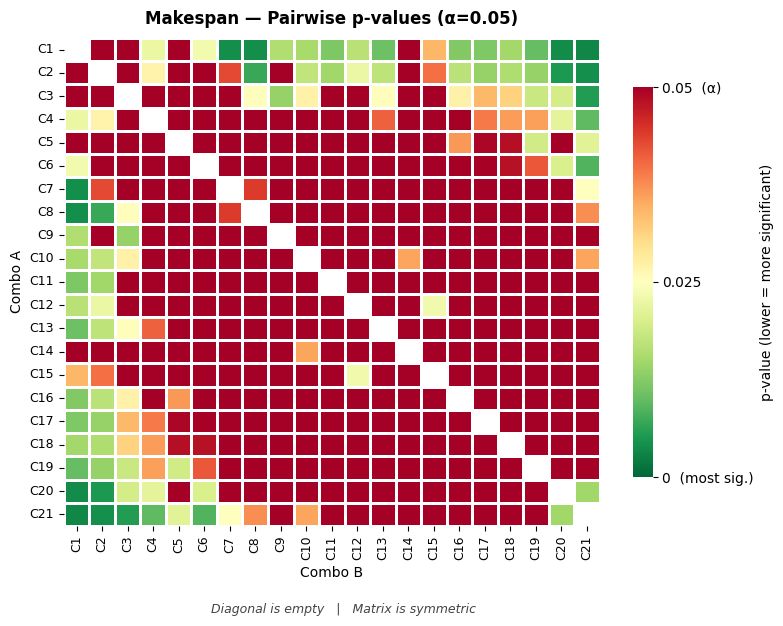

Saved: pvalue_heatmap_total_time.png


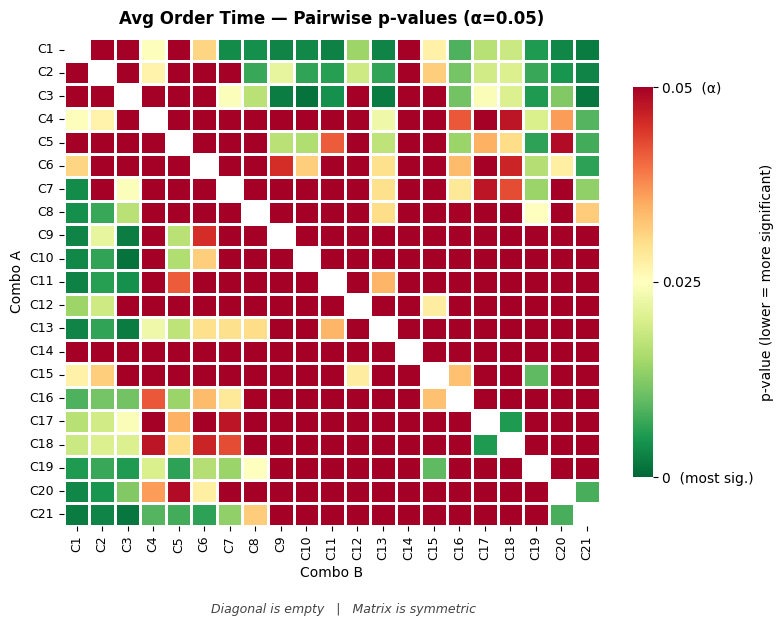

Saved: pvalue_heatmap_avg_order_time.png


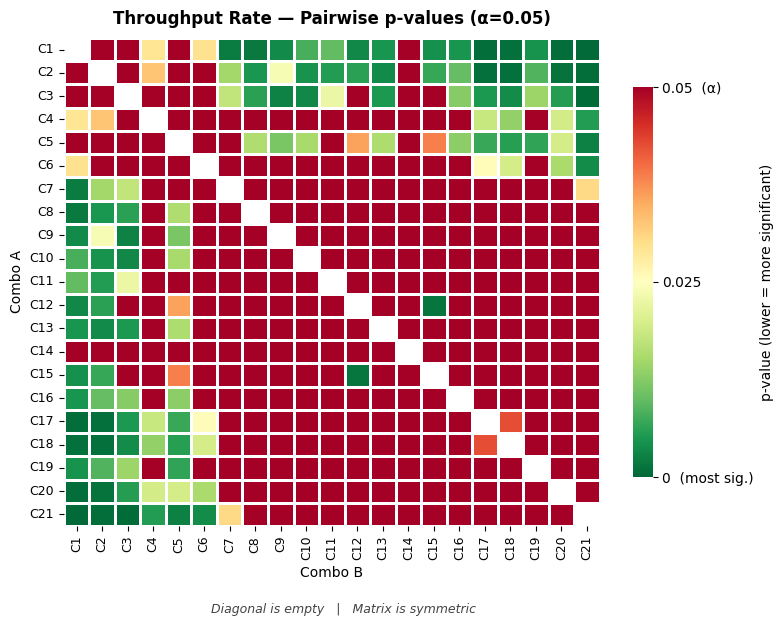

Saved: pvalue_heatmap_throughput_rate.png


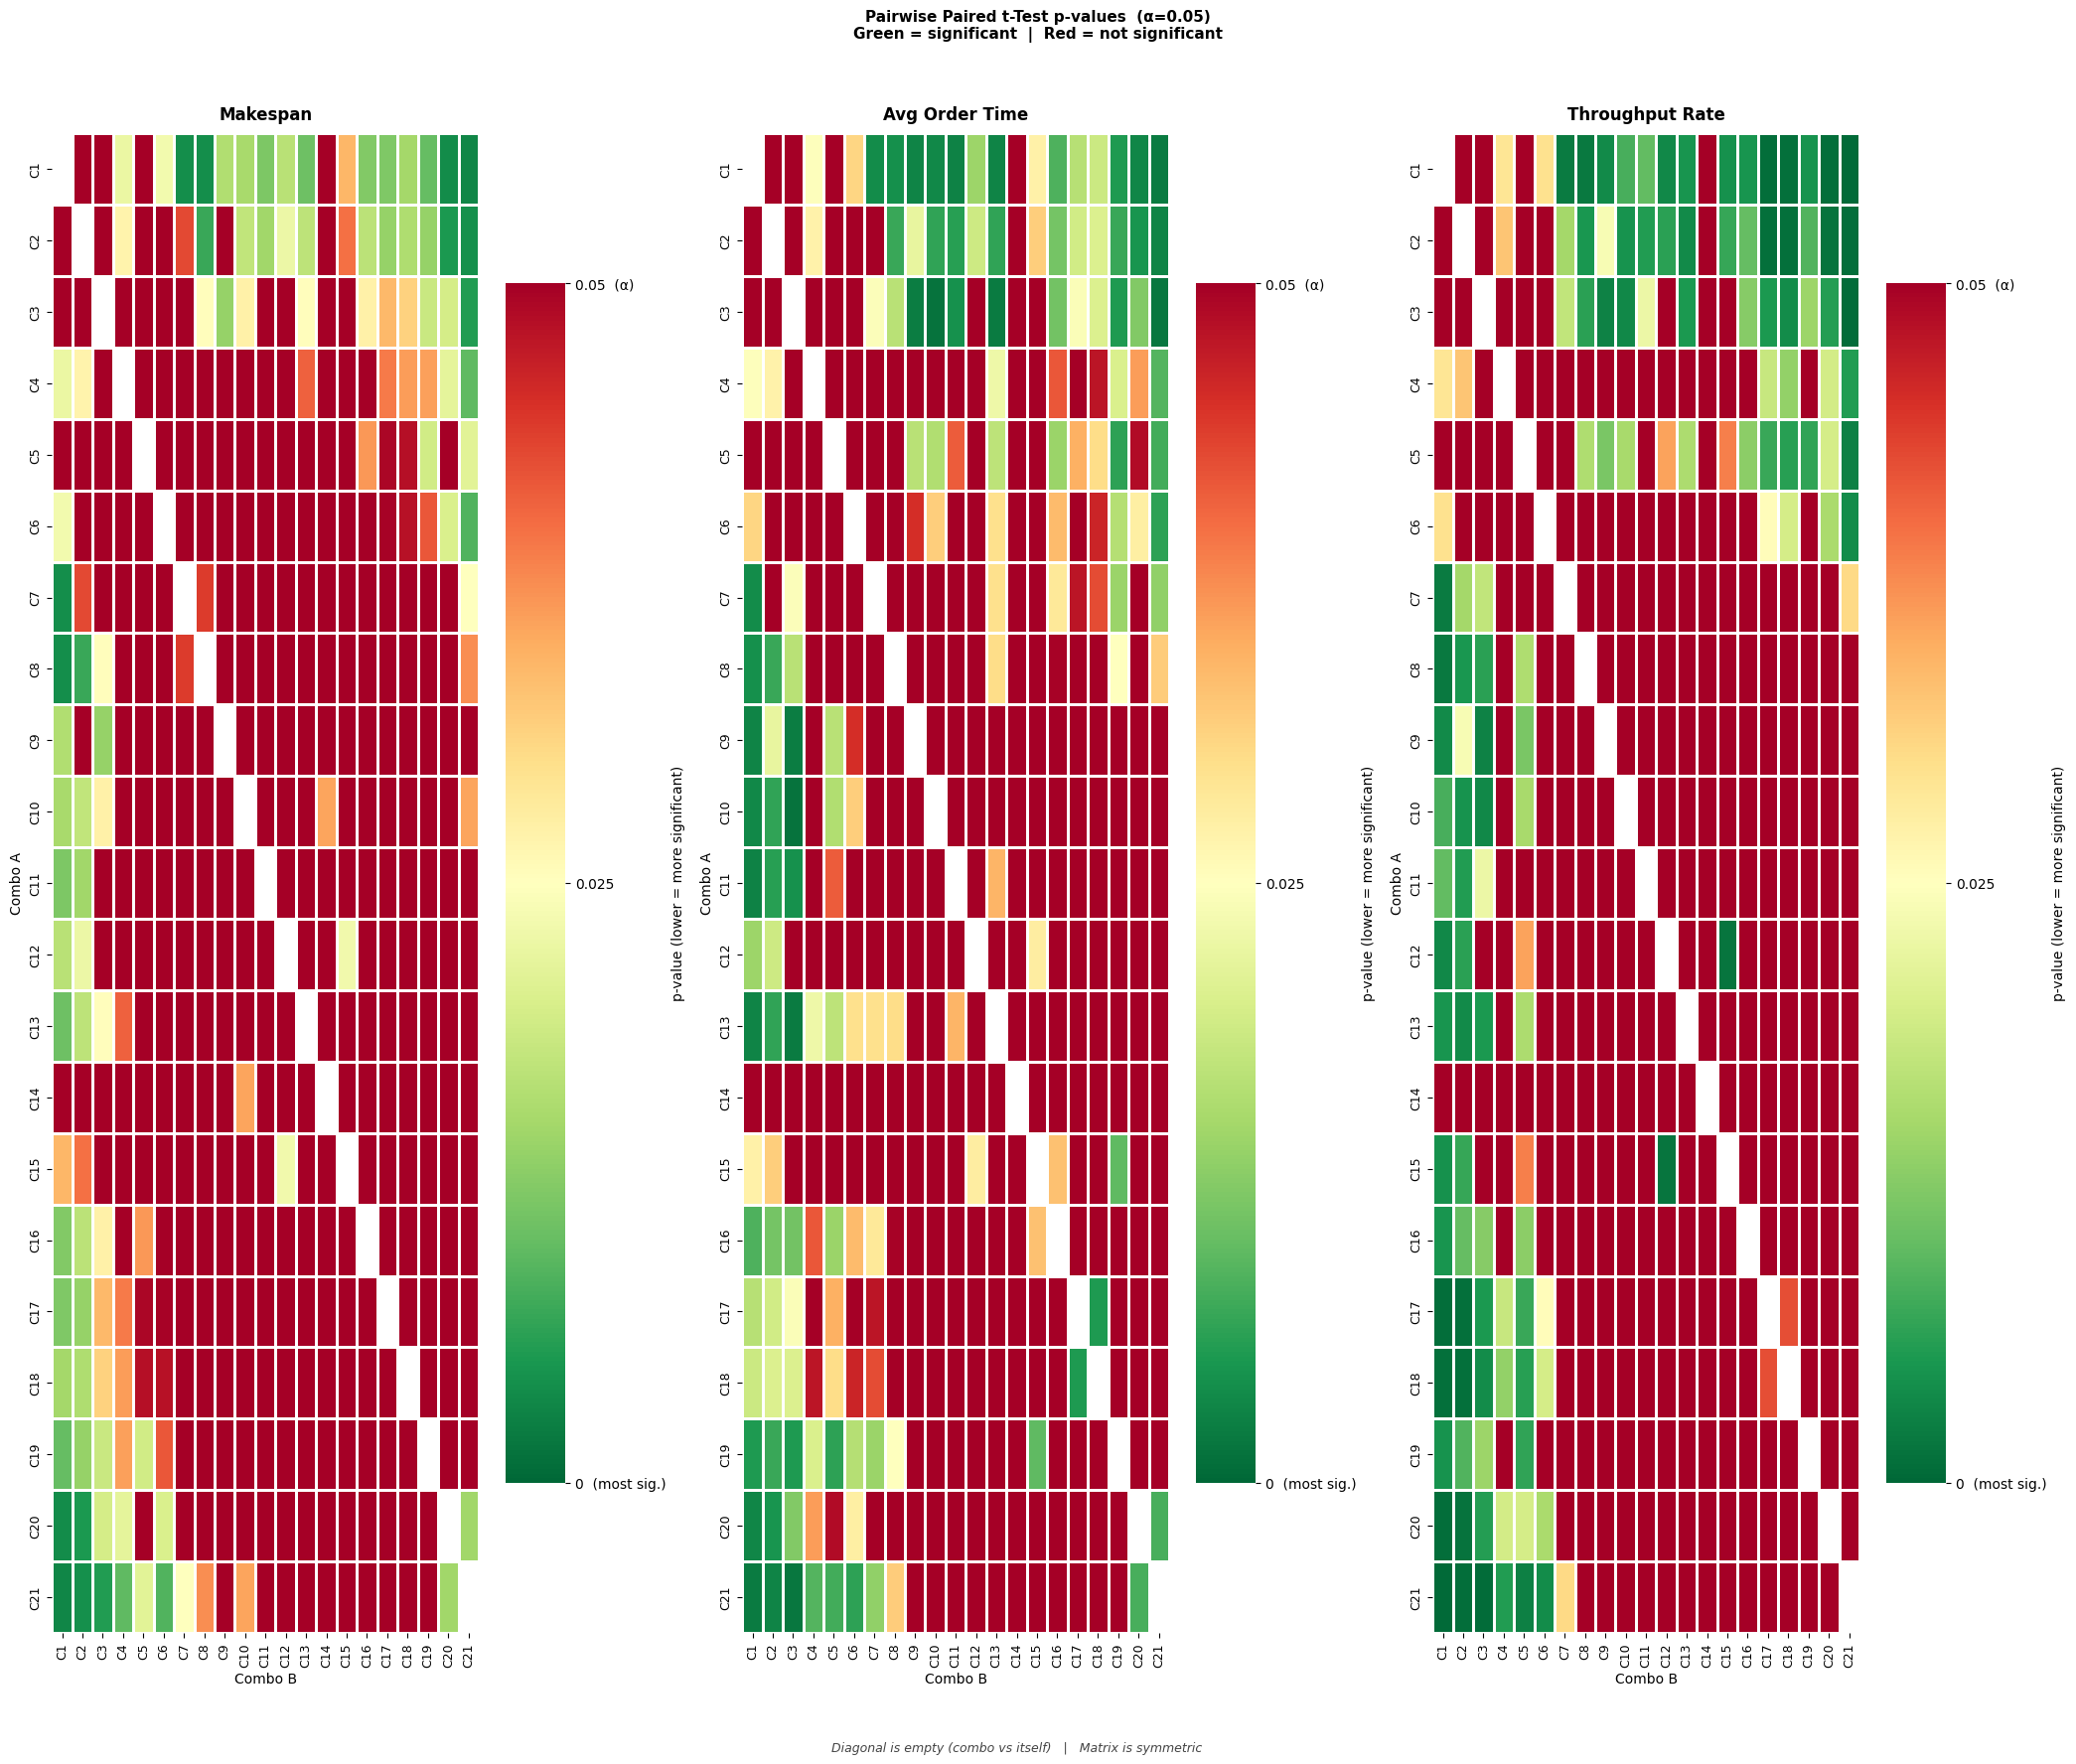

Saved: pvalue_heatmaps.png


In [64]:
def build_pvalue_matrix(df, metric):
    labels = [short_labels[c] for c in all_combos]
    mat    = pd.DataFrame(np.nan, index=labels, columns=labels)
    for a, b in all_pairs:
        r = paired_ttest(df, a, b, metric)
        if r:
            mat.loc[short_labels[a], short_labels[b]] = r['p_value']
            mat.loc[short_labels[b], short_labels[a]] = r['p_value']
    return mat

# Cache p-value matrices — run once, reused by all plots
pvalue_matrices = {
    metric: build_pvalue_matrix(df, metric)
    for metric in ['total_time', 'avg_order_time', 'throughput_rate']
}
print('P-value matrices cached.')

def plot_pvalue_heatmap(ax, metric, title):
    mat = pvalue_matrices[metric]
    sns.heatmap(
        mat, ax=ax,
        annot=None,
        cmap='RdYlGn_r',
        vmin=0, vmax=ALPHA,
        linewidths=0.8, linecolor='white',
        annot_kws={'size': max(7, 10 - n_combos // 3), 'va': 'center'},
        cbar_kws={
            'label': 'p-value (lower = more significant)',
            'shrink': 0.8,
            'ticks': [0, ALPHA/2, ALPHA],
        }
    )
    cbar = ax.collections[0].colorbar
    cbar.set_ticklabels(['0  (most sig.)', f'{ALPHA/2:.3f}', f'{ALPHA}  (α)'])
    ax.set_title(title, fontweight='bold', fontsize=12, pad=10)
    ax.set_xlabel('Combo B', fontsize=10)
    ax.set_ylabel('Combo A', fontsize=10)
    ax.tick_params(axis='both', labelsize=9)

metrics = [
    ('total_time',      'Makespan'),
    ('avg_order_time',  'Avg Order Time'),
    ('throughput_rate', 'Throughput Rate'),
]

# Individual plots
for metric, title in metrics:
    fig_single, ax_single = plt.subplots(figsize=(8, 6))
    plot_pvalue_heatmap(ax_single, metric, f'{title} — Pairwise p-values (α={ALPHA})')

    pos = ax_single.get_position()
    center = (pos.x0 + pos.x1) / 2
    fig_single.text(
        0.5 -0.03,
        f'Diagonal is empty   |   Matrix is symmetric',
        ha='center', fontsize=9, style='italic', color='#444444'
    )
    plt.tight_layout()
    fname = f'pvalue_heatmap_{metric}.png'
    # plt.savefig(fname, bbox_inches='tight', dpi=150)
    plt.show()
    # print(f'Saved: {fname}')

# Combined plot
fig, axes = plt.subplots(1, 3, figsize=(7 * 3, max(6, n_combos * 0.7 + 2)))
fig.suptitle(
    f'Pairwise Paired t-Test p-values  (α={ALPHA})\n'
    f'Green = significant  |  Red = not significant',
    fontsize=11, fontweight='bold', y=1.02
)
for ax, (metric, title) in zip(axes, metrics):
    plot_pvalue_heatmap(ax, metric, title)

ax_positions = [ax.get_position() for ax in axes]
left  = ax_positions[0].x0
right = ax_positions[-1].x1
center = (left + right) / 2

fig.text(
    center, -0.03,
    f'Diagonal is empty (combo vs itself)   |   Matrix is symmetric',
    ha='center', fontsize=9, style='italic', color='#444444'
)
plt.tight_layout()
# plt.savefig('pvalue_heatmaps.png', bbox_inches='tight', dpi=150)
plt.show()
# print('Saved: pvalue_heatmaps.png')

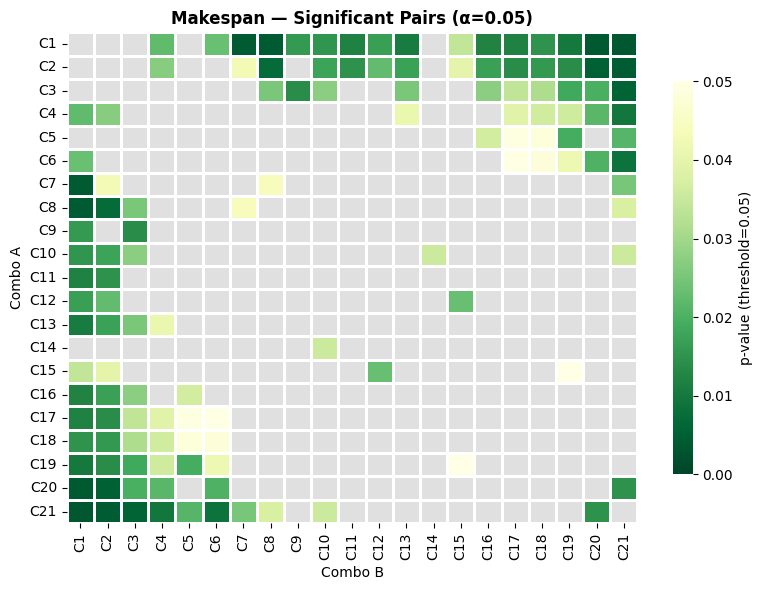

Saved: pvalue_heatmap_total_time.png


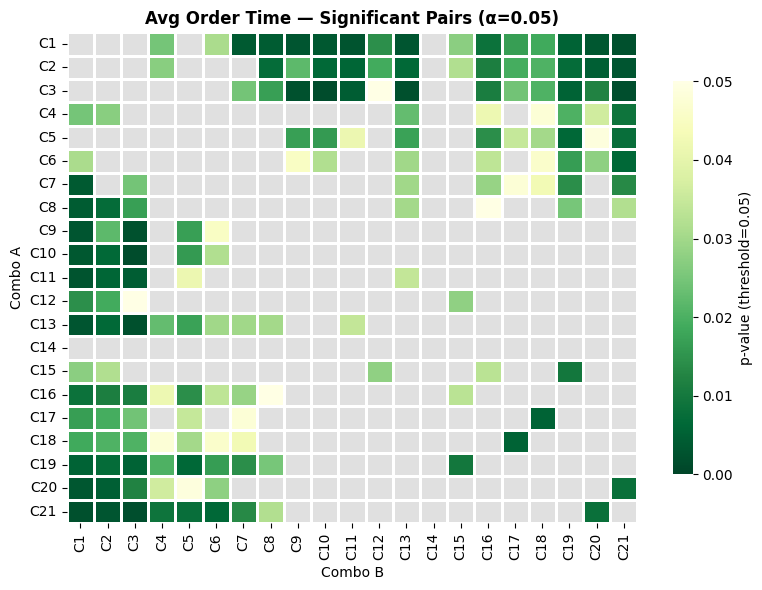

Saved: pvalue_heatmap_avg_order_time.png


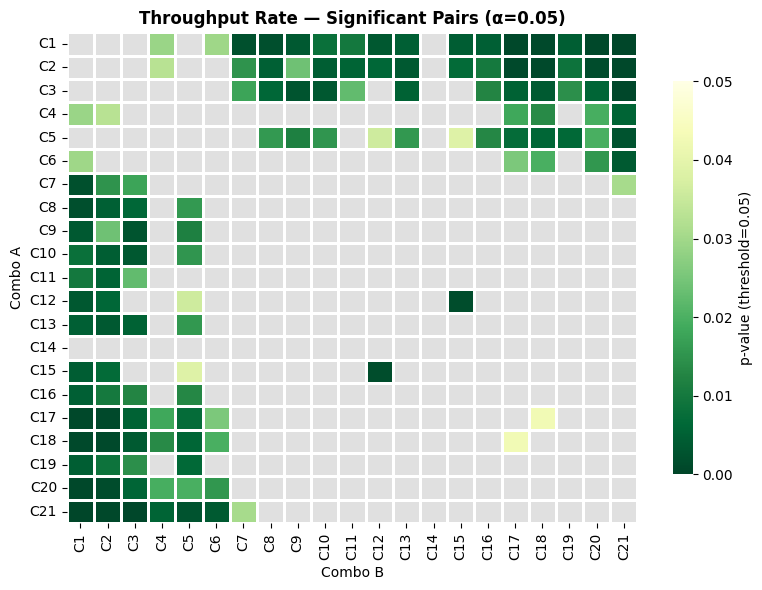

Saved: pvalue_heatmap_throughput_rate.png


In [58]:
for metric, title in [
    ('total_time',     'Makespan'),
    ('avg_order_time', 'Avg Order Time'),
    ('throughput_rate', 'Throughput Rate'),
]:
    mat = pvalue_matrices[metric]
    mat_sig = mat.copy()
    mat_sig[mat >= ALPHA] = np.nan

    annot = pd.DataFrame('', index=mat.index, columns=mat.columns)
    for i in range(len(mat)):
        for j in range(len(mat.columns)):
            val = mat.iloc[i, j]
            if not np.isnan(val) and val < ALPHA:
                annot.iloc[i, j] = f'{val:.3f}'

    # Individual plot
    fig_single, ax_single = plt.subplots(figsize=(8, 6))
    ax_single.set_facecolor('#e0e0e0')
    sns.heatmap(
        mat_sig, ax=ax_single,
        annot=False,
        cmap='YlGn_r',
        vmin=0, vmax=ALPHA,
        linewidths=0.8, linecolor='white',
        annot_kws={'size': max(7, 10 - n_combos // 3)},
        cbar_kws={'label': f'p-value (threshold={ALPHA})', 'shrink': 0.8},
        mask=mat_sig.isna(),
    )
    ax_single.set_title(f'{title} — Significant Pairs (α={ALPHA})', fontweight='bold', fontsize=12)
    ax_single.set_xlabel('Combo B', fontsize=10)
    ax_single.set_ylabel('Combo A', fontsize=10)
    plt.tight_layout()
    fname = f'pvalue_heatmap_{metric}.png'
    # plt.savefig(fname, bbox_inches='tight', dpi=150)
    plt.show()
    # print(f'Saved: {fname}')

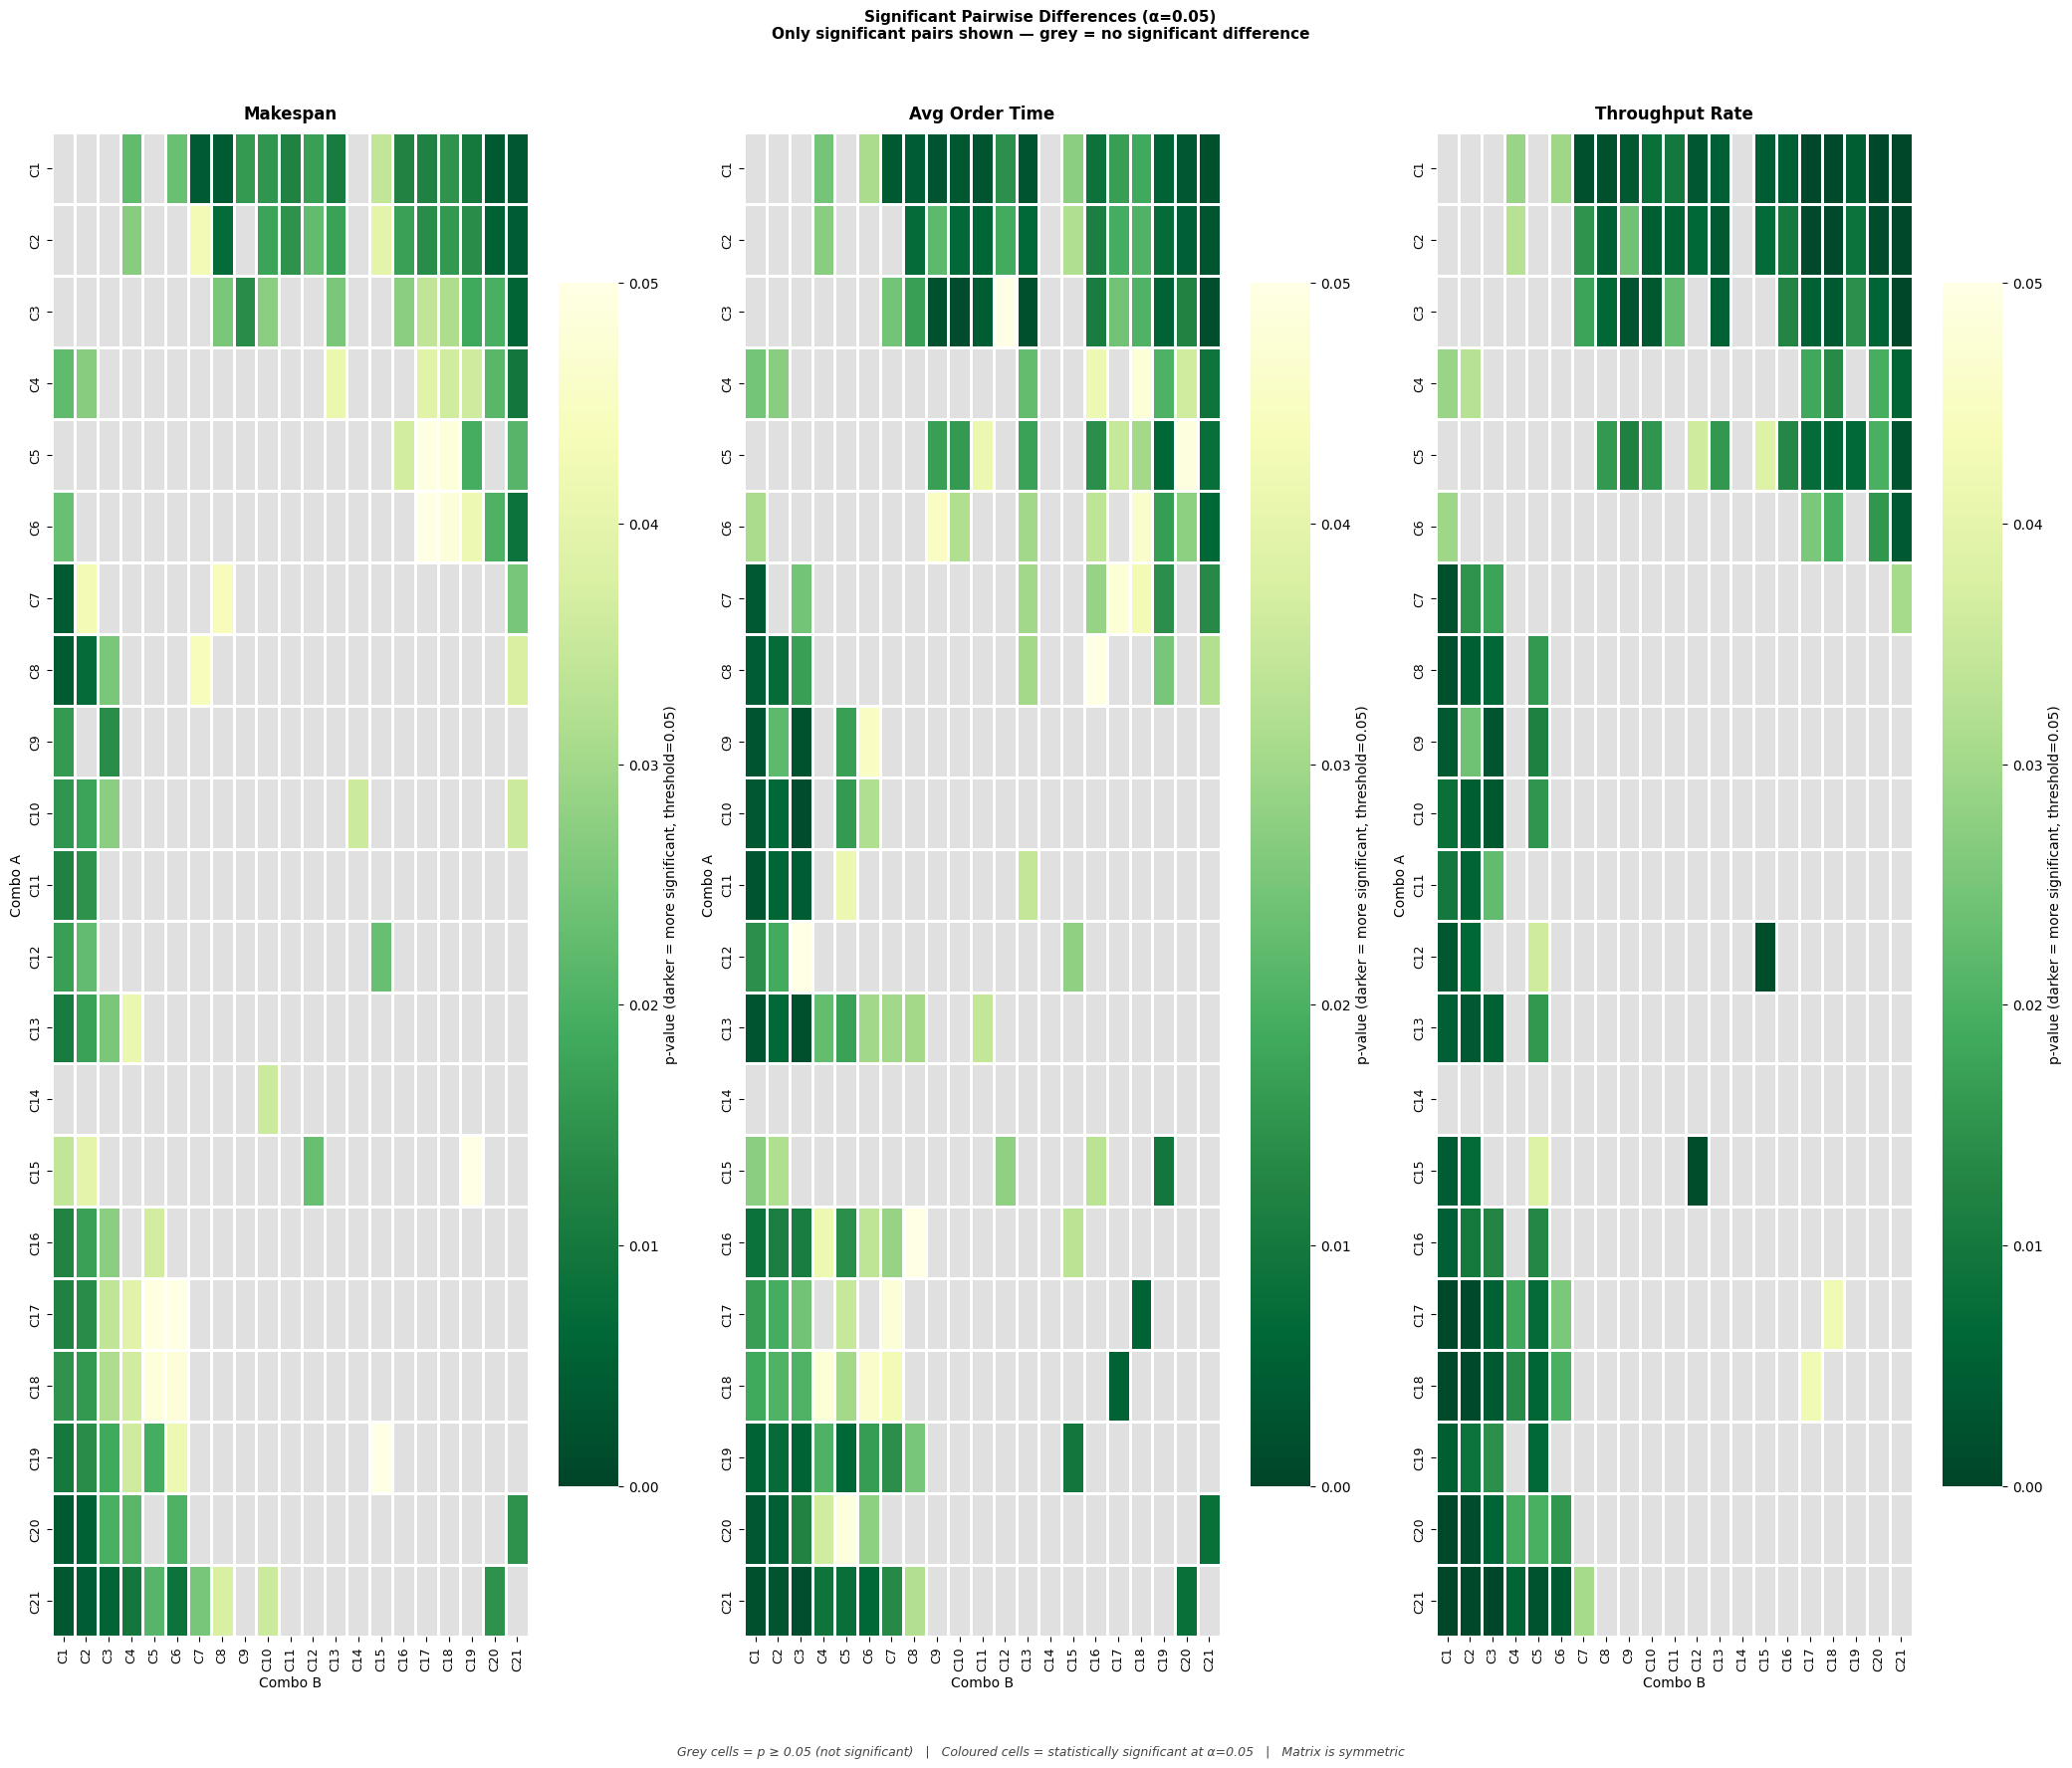

Saved: pvalue_heatmaps_significant.png


In [59]:

fig, axes = plt.subplots(1, 3, figsize=(7 * 3, max(6, n_combos * 0.7 + 2)))
fig.suptitle(
    f'Significant Pairwise Differences (α={ALPHA})\n'
    f'Only significant pairs shown — grey = no significant difference',
    fontsize=11, fontweight='bold', y=1.02
)

for ax, (metric, title) in zip(axes, [
    ('total_time',     'Makespan'),
    ('avg_order_time', 'Avg Order Time'),
    ('throughput_rate',  'Throughput Rate'),
]):
    mat = pvalue_matrices[metric]

    mat_sig = mat.copy()
    mat_sig[mat >= ALPHA] = np.nan

    annot = pd.DataFrame('', index=mat.index, columns=mat.columns)
    for i in range(len(mat)):
        for j in range(len(mat.columns)):
            val = mat.iloc[i, j]
            if not np.isnan(val) and val < ALPHA:
                annot.iloc[i, j] = f'{val:.3f}'

    ax.set_facecolor('#e0e0e0')

    sns.heatmap(
        mat_sig, ax=ax,
        annot=False,
        cmap='YlGn_r',
        vmin=0, vmax=ALPHA,
        linewidths=0.8, linecolor='white',
        annot_kws={'size': max(7, 10 - n_combos // 3)},
        cbar_kws={
            'label': f'p-value (darker = more significant, threshold={ALPHA})',
            'shrink': 0.8,
        },
        mask=mat_sig.isna(),
    )

    ax.set_title(f'{title}\n({n} combos at α={ALPHA})', fontweight='bold', fontsize=11)
    ax.set_title(title, fontweight='bold', fontsize=12, pad=10)
    ax.set_xlabel('Combo B', fontsize=10)
    ax.set_ylabel('Combo A', fontsize=10)
    ax.tick_params(axis='both', labelsize=9)

fig.text(
    0.5, -0.03,
    f'Grey cells = p ≥ {ALPHA} (not significant)   |   '
    f'Coloured cells = statistically significant at α={ALPHA}   |   Matrix is symmetric',
    ha='center', fontsize=9, style='italic', color='#444444'
)

plt.tight_layout()
# plt.savefig('pvalue_heatmaps_significant.png', bbox_inches='tight', dpi=150)
plt.show()
# print('Saved: pvalue_heatmaps_significant.png')

## 4. Summary

In [68]:
import os 

best_combo = all_combos[0]
top_x = 10
top_combos = all_combos[:top_x]

print('Top Combos (ranked by mean makespan):')
print('=' * 60)
for i, combo in enumerate(top_combos):
    mean_makespan   = df[df['combo'] == combo]['total_time'].mean()
    mean_order_time = df[df['combo'] == combo]['avg_order_time'].mean()
    print(f'{i+1}. {combo}')
    print(f'   Code            : {short_labels[combo]}')
    print(f'   Mean Makespan   : {mean_makespan:.4f}')
    print(f'   Mean Avg Order  : {mean_order_time:.4f}')
    print()

top_by_order_time = (
    df.groupby('combo')['avg_order_time'].mean()
    .sort_values()  # ascending = lowest avg order time first (best)
    .index[:top_x]
    .tolist()
)

results_folder = "Data/statistical_analysis_results/"
os.makedirs(results_folder, exist_ok=True)
desc_df.to_csv(f'{results_folder}heuristic_summary.csv', index=False)
label_legend.to_csv(f'{results_folder}combo_codes.csv', index=False)

for metric, result_df in ttest_results.items():
    result_df.to_csv(f'{results_folder}ttest_results_{metric}.csv', index=False)

print('Exported:')
print('  heuristic_summary.csv        — descriptive stats for all combos')
print('  combo_codes.csv              — code-to-combo name mapping')
for metric in ttest_results:
    print(f'  ttest_results_{metric}.csv  — pairwise t-test results')

Top Combos (ranked by mean makespan):
1. algorithm2_tote_overlap | smart_active_need_weighted | critical_first
   Code            : C1
   Mean Makespan   : 218.3523
   Mean Avg Order  : 138.2231

2. algorithm2_tote_overlap | smart_active_need_weighted | fixed
   Code            : C2
   Mean Makespan   : 220.5682
   Mean Avg Order  : 140.7490

3. algorithm2_tote_overlap | smart_active_need | critical_first
   Code            : C3
   Mean Makespan   : 227.1875
   Mean Avg Order  : 143.0966

4. algorithm4_combined_overlap | smart_active_need_weighted | fixed
   Code            : C4
   Mean Makespan   : 231.7857
   Mean Avg Order  : 152.3864

5. algorithm2_tote_overlap | smart_active_need | fixed
   Code            : C5
   Mean Makespan   : 234.4565
   Mean Avg Order  : 149.5998

6. algorithm4_combined_overlap | smart_active_need_weighted | critical_first
   Code            : C6
   Mean Makespan   : 237.7841
   Mean Avg Order  : 154.9277

7. algorithm4_combined_overlap | smart_active_need 

In [66]:
TOP_X = 10

rows = []
for col, label, ascending in [
    ('total_time',     'Makespan',       True),
    ('avg_order_time', 'Avg Order Time', True),
    ('throughput_rate',  'Throughput Rate',  False),
]:
    ranked = df.groupby('combo')[col].mean().sort_values(ascending=ascending)
    top_combos = ranked.index[:TOP_X]
    for rank, combo in enumerate(top_combos, 1):
        parts = combo.split(' | ')
        rows.append({
            'Metric'    : label,
            'Rank'      : rank,
            'Combo'     : combo,
            'Code'      : short_labels[combo],
            'Order Seq' : parts[0],
            'Tote Seq'  : parts[1],
            'Item Seq'  : parts[2],
            'Mean'      : round(ranked[combo], 4),
        })

top_df = pd.DataFrame(rows)

for scope, label in [
    (top_df,                                              f'All Metrics'),
    (top_df[top_df['Metric'] == 'Makespan'],              f'Makespan only (max {TOP_X})'),
    (top_df[top_df['Metric'] == 'Avg Order Time'],        f'Avg Order Time only (max {TOP_X})'),
]:
    print(f'\nDominance count — {label}:')
    print('-' * 50)
    max_count = len(scope)
    for seq_col, seq_label in [
        ('Order Seq', 'Order Sequencing'),
        ('Tote Seq',  'Tote Sequencing'),
        ('Item Seq',  'Item Sequencing'),
    ]:
        counts = scope[seq_col].value_counts()
        print(f'\n  {seq_label}:')
        for val, cnt in counts.items():
            bar = '█' * cnt
            print(f'    {val:<45} {cnt:>2} / {max_count}  {bar}')


Dominance count — All Metrics:
--------------------------------------------------

  Order Sequencing:
    algorithm2_tote_overlap                       12 / 30  ████████████
    algorithm4_combined_overlap                   12 / 30  ████████████
    algorithm1_load_balance                        4 / 30  ████
    fifo_all                                       1 / 30  █
    algorithm3_itemtype_overlap                    1 / 30  █

  Tote Sequencing:
    smart_active_need                             16 / 30  ████████████████
    smart_active_need_weighted                    13 / 30  █████████████
    fifo                                           1 / 30  █

  Item Sequencing:
    fixed                                         16 / 30  ████████████████
    critical_first                                14 / 30  ██████████████

Dominance count — Makespan only (max 10):
--------------------------------------------------

  Order Sequencing:
    algorithm2_tote_overlap                        